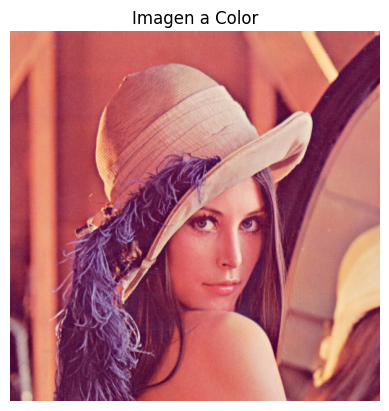

In [31]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import urllib.request

# Descargamos una imagen de internet para usarla en nuestro ejemplo
url_imagen = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
ruta_imagen_color = "imagen_descargada.jpg"
urllib.request.urlretrieve(url_imagen, ruta_imagen_color)

# Ejemplo 1: Cargar una imagen a color
# cv2.imread lee la imagen de la ruta especificada. Por defecto, lee en formato BGR (Azul, Verde, Rojo)
imagen_color = cv2.imread(ruta_imagen_color)

if imagen_color is None:
    print("Error: No se pudo cargar la imagen a color. Verifica la ruta o URL.")
else:
    # OpenCV usa BGR, pero Matplotlib usa RGB. 
    # Convertimos el espacio de color para que los colores se muestren correctamente
    imagen_color_rgb = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)
    
    # Mostramos la imagen
    plt.imshow(imagen_color_rgb)
    plt.axis("off") # Ocultamos los ejes para una visualización más limpia
    plt.title("Imagen a Color")
    plt.show()

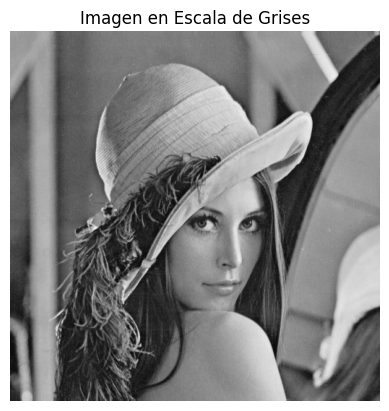

In [32]:
# Ejemplo 2: Convertir una imagen a escala de grises
# Reutilizamos la imagen descargada en el paso anterior
# El parámetro cv2.IMREAD_GRAYSCALE le indica a OpenCV que cargue la imagen directamente en un solo canal (escala de grises)
imagen_gris = cv2.imread(ruta_imagen_color, cv2.IMREAD_GRAYSCALE)

if imagen_gris is None:
    print("Error: No se pudo cargar la imagen en escala de grises.")
else:
    # Mostramos la imagen. El parámetro cmap="gray" es necesario para que matplotlib la interprete como grises
    plt.imshow(imagen_gris, cmap="gray")
    plt.axis("off") # Ocultamos los ejes
    plt.title("Imagen en Escala de Grises")
    plt.show()

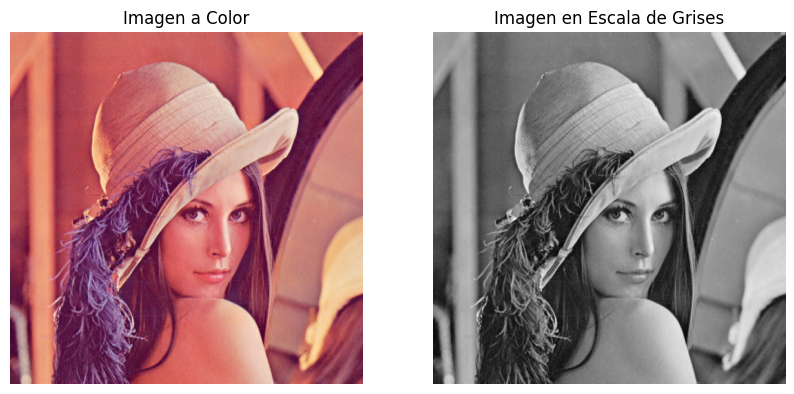

Dimensiones de la imagen a color (Alto, Ancho, Canales): (512, 512, 3)
Dimensiones de la imagen en escala de grises (Alto, Ancho): (512, 512)


In [33]:
# Ejemplo 3: Obtener dimensiones de las imagenes color y gris
import cv2
import matplotlib.pyplot as plt

# Reutilizamos las imágenes previamente cargadas/convertidas
if imagen_color is None:
    print("Error: No se pudo cargar la imagen.")
else:
    # Mostrar la imagen original y en escala de grises una al lado de la otra
    plt.figure(figsize=(10, 5)) # Definimos el tamaño de la figura en pulgadas
    
    # Subplot 1: Imagen a color
    plt.subplot(1, 2, 1) # 1 fila, 2 columnas, posición 1
    plt.imshow(cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB))
    plt.title("Imagen a Color")
    plt.axis("off")

    # Subplot 2: Imagen en escala de grises
    plt.subplot(1, 2, 2) # 1 fila, 2 columnas, posición 2
    plt.imshow(imagen_gris, cmap="gray")
    plt.title("Imagen en Escala de Grises")
    plt.axis("off")

    plt.show()

    # Imprimir las dimensiones de las imágenes
    # El atributo shape devuelve una tupla: (alto, ancho, canales) para color, y (alto, ancho) para grises
    print("Dimensiones de la imagen a color (Alto, Ancho, Canales):", imagen_color.shape)
    print("Dimensiones de la imagen en escala de grises (Alto, Ancho):", imagen_gris.shape)

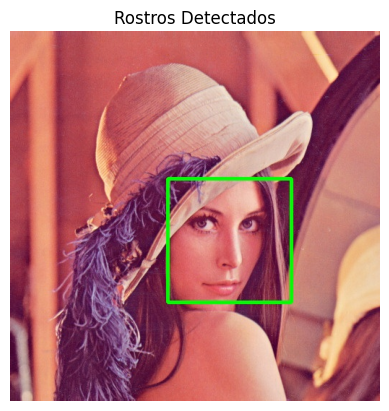

In [34]:
    # Ejemplo 4: Detectar rostro de personas
    import cv2
    import matplotlib.pyplot as plt
    import urllib.request

    # Descargamos el modelo pre-entrenado de OpenCV (Haar Cascade) para detección de rostros frontales
    url_cascade = "https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml"
    ruta_cascade = "haarcascade_frontalface_default.xml"
    urllib.request.urlretrieve(url_cascade, ruta_cascade)

    # Descargamos una imagen con rostros (usaremos a lena.jpg que tiene un rostro claro)
    url_rostro = "https://raw.githubusercontent.com/opencv/opencv/master/samples/data/lena.jpg"
    ruta_rostro = "rostro_detect.jpg"
    urllib.request.urlretrieve(url_rostro, ruta_rostro)

    def detect(filename):
        # Inicializamos el clasificador con el archivo XML que contiene el modelo
        face_cascade = cv2.CascadeClassifier(ruta_cascade)
        
        # Leemos la imagen y la convertimos a escala de grises, que es requerido por el detector
        img = cv2.imread(filename)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # detectMultiScale busca los objetos (rostros)
        # scaleFactor compensa si el rostro está más cerca o más lejos
        # minNeighbors especifica cuántos rostros cercanos se necesitan para confirmar que es un rostro real
        faces = face_cascade.detectMultiScale(gray, scaleFactor=1.3, minNeighbors=5)
        
        # Dibujamos un rectángulo verde alrededor de cada rostro detectado
        for (x, y, w, h) in faces:
            img = cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 3)
            
        # Guardamos el resultado en un nuevo archivo
        cv2.imwrite('rostros_detectados.jpg', img)

    # Llamamos a la función con la imagen descargada
    detect(ruta_rostro)

    # Cargamos el resultado y lo mostramos con Matplotlib
    imagen_resultado = cv2.imread('rostros_detectados.jpg')
    if imagen_resultado is not None:
        imagen_resultado_rgb = cv2.cvtColor(imagen_resultado, cv2.COLOR_BGR2RGB)
        plt.imshow(imagen_resultado_rgb)
        plt.title("Rostros Detectados")
        plt.axis("off")
        plt.show()
    else:
        print("Error procesando la detección.")

Archivo de audio mono generado con éxito.


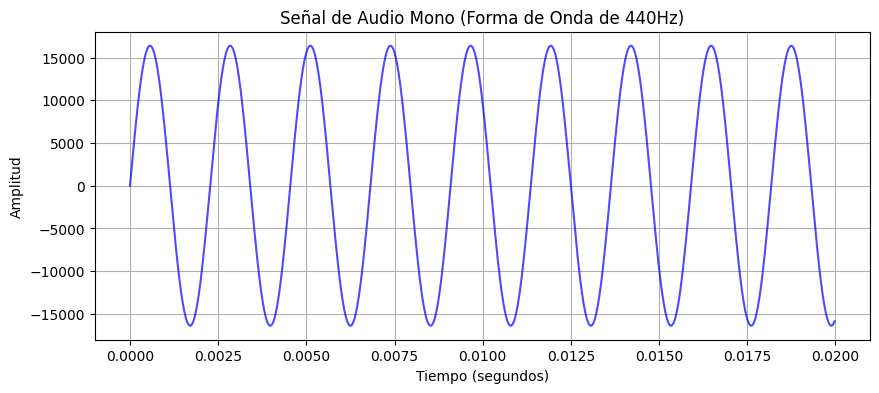

In [35]:
    # ### 2. Audio
    # Las señales de audio también son fundamentales en percepción computacional. A continuación, veremos dos ejemplos: la generación y carga de un archivo de audio mono, y la visualización de su forma de onda.

    import numpy as np
    import matplotlib.pyplot as plt
    import wave # Usamos la librería estándar 'wave' para crear y leer archivos de audio

    # Ejemplo 1: Generar, guardar y cargar un archivo de audio mono
    ruta_audio_mono = "audio_mono_generado.wav"

    # 1. Generamos un tono puro (Onda senoidal) a 440 Hz (Nota La)
    frecuencia_muestreo_mono = 44100
    duracion = 1.0 # segundos
    frecuencia_tono = 440.0 # Hz
    tiempo_gen = np.linspace(0, duracion, int(frecuencia_muestreo_mono * duracion), endpoint=False)
    onda = 0.5 * np.sin(2 * np.pi * frecuencia_tono * tiempo_gen) # Amplitud de 0.5
    onda_enteros = np.int16(onda * 32767) # Convertimos a enteros de 16 bits

    # Guardamos el audio generado en un archivo WAV
    with wave.open(ruta_audio_mono, 'w') as wav_file:
        wav_file.setnchannels(1) # 1 canal = Mono
        wav_file.setsampwidth(2) # 2 bytes = 16 bits
        wav_file.setframerate(frecuencia_muestreo_mono)
        wav_file.writeframes(onda_enteros.tobytes())
        print("Archivo de audio mono generado con éxito.")

    # 2. Cargamos el archivo de audio que acabamos de crear
    try:
        with wave.open(ruta_audio_mono, 'rb') as wav_file:
            frec_muestreo = wav_file.getframerate()
            n_frames = wav_file.getnframes()
            audio_data = wav_file.readframes(n_frames)
            audio_mono = np.frombuffer(audio_data, dtype=np.int16)
            
            tiempo_mono = np.arange(len(audio_mono)) / frec_muestreo
            
            # Graficamos un pequeño segmento de la señal (los primeros 0.02 segundos) para ver la onda
            segmento = int(frec_muestreo * 0.02)
            
            plt.figure(figsize=(10, 4))
            plt.plot(tiempo_mono[:segmento], audio_mono[:segmento], color='blue', alpha=0.7)
            plt.title("Señal de Audio Mono (Forma de Onda de 440Hz)")
            plt.xlabel("Tiempo (segundos)")
            plt.ylabel("Amplitud")
            plt.grid(True)
            plt.show()
    except Exception as e:
        print(f"Error al procesar el audio mono: {e}")

Archivo de audio estéreo generado con éxito.


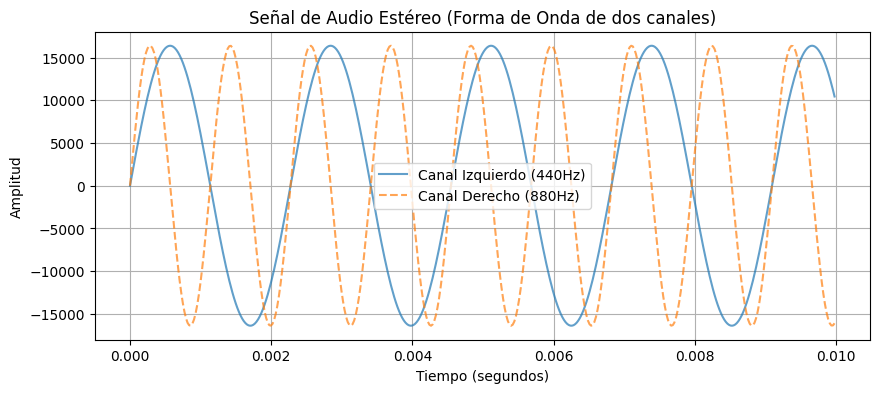

In [36]:
# Ejemplo 2: Generar, guardar y cargar un archivo de audio estéreo
# Utilizaremos la misma técnica para generar un audio estéreo con dos tonos distintos:
# Canal Izquierdo: 440 Hz
# Canal Derecho: 880 Hz

ruta_audio_estereo = "audio_estereo_generado.wav"

frecuencia_muestreo_estereo = 44100
duracion = 1.0 # segundos
frec_izq = 440.0
frec_der = 880.0
tiempo_gen = np.linspace(0, duracion, int(frecuencia_muestreo_estereo * duracion), endpoint=False)

onda_izq = 0.5 * np.sin(2 * np.pi * frec_izq * tiempo_gen)
onda_der = 0.5 * np.sin(2 * np.pi * frec_der * tiempo_gen)

# Convertimos ambas ondas a enteros de 16 bits
onda_izq_int16 = np.int16(onda_izq * 32767)
onda_der_int16 = np.int16(onda_der * 32767)

# Para un archivo estéreo, los datos deben estar intercalados: [Izquierdo, Derecho, Izquierdo, Derecho...]
onda_estereo = np.empty((onda_izq_int16.size + onda_der_int16.size,), dtype=np.int16)
onda_estereo[0::2] = onda_izq_int16
onda_estereo[1::2] = onda_der_int16

# Guardamos el archivo estéreo
with wave.open(ruta_audio_estereo, 'w') as wav_file:
    wav_file.setnchannels(2) # 2 canales = Estéreo
    wav_file.setsampwidth(2)
    wav_file.setframerate(frecuencia_muestreo_estereo)
    wav_file.writeframes(onda_estereo.tobytes())
    print("Archivo de audio estéreo generado con éxito.")

# Cargamos el archivo de audio estéreo
try:
    with wave.open(ruta_audio_estereo, 'rb') as wav_file:
        frec_muestreo = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        n_channels = wav_file.getnchannels()
        
        audio_data = wav_file.readframes(n_frames)
        audio_estereo_cargado = np.frombuffer(audio_data, dtype=np.int16)
        
        tiempo_estereo = np.arange(n_frames) / frec_muestreo
        
        plt.figure(figsize=(10, 4))
        
        if n_channels == 2:
            audio_estereo_cargado = audio_estereo_cargado.reshape(-1, 2)
            
            # Graficamos un segmento de 0.01 segundos
            segmento = int(frec_muestreo * 0.01)
            
            plt.plot(tiempo_estereo[:segmento], audio_estereo_cargado[:segmento, 0], label="Canal Izquierdo (440Hz)", alpha=0.7)
            plt.plot(tiempo_estereo[:segmento], audio_estereo_cargado[:segmento, 1], label="Canal Derecho (880Hz)", alpha=0.7, linestyle='--')
        
        plt.title("Señal de Audio Estéreo (Forma de Onda de dos canales)")
        plt.xlabel("Tiempo (segundos)")
        plt.ylabel("Amplitud")
        plt.legend()
        plt.grid(True)
        plt.show()
except Exception as e:
    print(f"Error al procesar el audio estéreo: {e}")

Simulando datos de un sensor de temperatura...
Muestra 1 - Temperatura: 20.82°C
Muestra 2 - Temperatura: 23.05°C
Muestra 3 - Temperatura: 23.60°C
Muestra 4 - Temperatura: 27.60°C
Muestra 5 - Temperatura: 28.52°C
Muestra 6 - Temperatura: 22.63°C
Muestra 7 - Temperatura: 24.23°C
Muestra 8 - Temperatura: 24.69°C
Muestra 9 - Temperatura: 21.16°C
Muestra 10 - Temperatura: 24.57°C


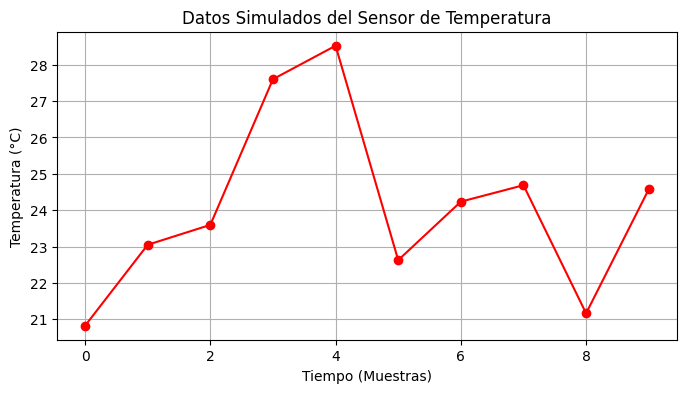

In [37]:
# ### 3. IoT (Internet de las Cosas)
# Los sensores IoT son fundamentales para la captura de datos en tiempo real. A continuación, veremos dos ejemplos: simulación de un sensor de temperatura y un sensor de humedad.

import random
import time
import matplotlib.pyplot as plt

# Ejemplo 1: Simulación de un sensor de temperatura
def simular_temperatura():
    # Simulamos una lectura de temperatura devolviendo un valor aleatorio entre 20.0 y 30.0 °C
    return random.uniform(20.0, 30.0)

print("Simulando datos de un sensor de temperatura...")
datos_temperatura = []

# Recolectaremos 10 muestras
for i in range(10):
    temperatura = simular_temperatura()
    datos_temperatura.append(temperatura)
    print(f"Muestra {i+1} - Temperatura: {temperatura:.2f}°C")
    # time.sleep(0.2)  # Pausa breve simulando el tiempo de espera del sensor (comentado para no demorar)

# Graficamos la serie temporal de temperaturas
plt.figure(figsize=(8, 4))
plt.plot(datos_temperatura, marker="o", color="red", linestyle='-')
plt.title("Datos Simulados del Sensor de Temperatura")
plt.xlabel("Tiempo (Muestras)")
plt.ylabel("Temperatura (°C)")
plt.grid(True)
plt.show()

Simulando datos de un sensor de humedad...
Muestra 1 - Humedad: 48.79%
Muestra 2 - Humedad: 4.23%
Muestra 3 - Humedad: 13.53%
Muestra 4 - Humedad: 82.21%
Muestra 5 - Humedad: 53.32%
Muestra 6 - Humedad: 47.47%
Muestra 7 - Humedad: 20.45%
Muestra 8 - Humedad: 77.51%
Muestra 9 - Humedad: 68.35%
Muestra 10 - Humedad: 22.54%


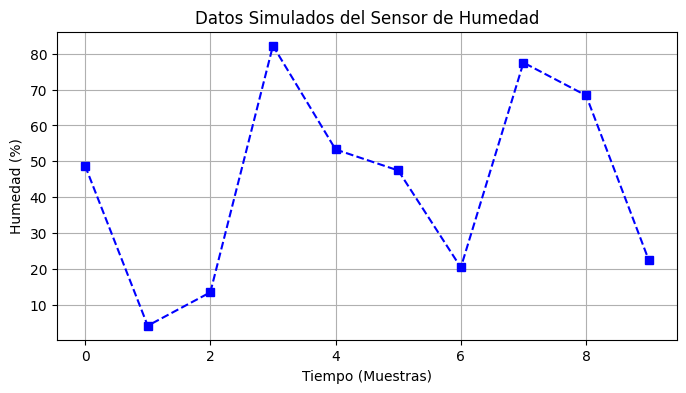

In [38]:
# Ejemplo 2: Simulación de un sensor de humedad
def simular_humedad():
    # Simulamos una lectura de humedad devolviendo un porcentaje aleatorio entre 0% y 100%
    return random.uniform(0.0, 100.0)

print("Simulando datos de un sensor de humedad...")
datos_humedad = []

# Recolectaremos 10 muestras
for i in range(10):
    humedad = simular_humedad()
    datos_humedad.append(humedad)
    print(f"Muestra {i+1} - Humedad: {humedad:.2f}%")
    # time.sleep(0.2)  # Pausa breve simulando el tiempo de espera del sensor

# Graficamos la serie temporal de humedad
plt.figure(figsize=(8, 4))
plt.plot(datos_humedad, marker="s", color="blue", linestyle='--')
plt.title("Datos Simulados del Sensor de Humedad")
plt.xlabel("Tiempo (Muestras)")
plt.ylabel("Humedad (%)")
plt.grid(True)
plt.show()

### Práctica de Laboratorio

**Objetivo:** Aplicar los conceptos básicos aprendidos en teoria y labde procesamiento de imágenes, audio e IoT de forma práctica.

**Instrucciones:**

Añade una o más celdas de código al final de este notebook para resolver los siguientes ejercicios:

1. **Imágenes:** Carga una imagen a color (puedes descargar una usando `urllib.request.urlretrieve` como vimos, o usar una imagen local), conviértela a escala de grises y aplícale un filtro de desenfoque básico usando OpenCV (`cv2.blur` o `cv2.GaussianBlur`). Muestra la imagen original y la procesada una al lado de la otra usando `matplotlib`.
2. **Audio:** Usando `numpy` y `wave`, genera un archivo de audio estéreo de 2 segundos de duración donde el **Canal Izquierdo** tenga una frecuencia de **500 Hz** y el **Canal Derecho** tenga una frecuencia de **1000 Hz**. Luego carga el audio generado y grafica los primeros 0.02 segundos de ambos canales para verificar las ondas.
3. **IoT:** Simula un sensor de **Luminosidad** que devuelva valores aleatorios entre 0 y 1000 lux. Recolecta 15 muestras en un bucle y grafica los resultados a lo largo del tiempo usando una línea de color verde (`color="green"`) y marcadores en forma de triángulo (`marker="^"`).

### IMAGEN:

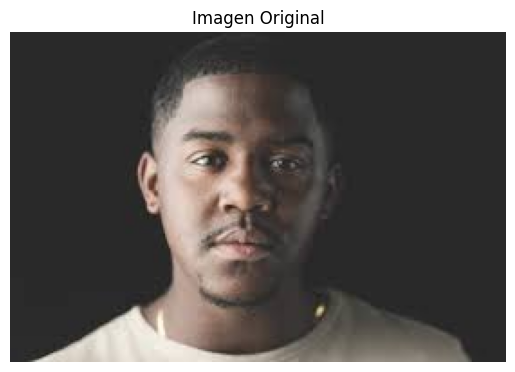

In [39]:
# Importamos las librerías necesarias
import cv2                          # Librería para procesamiento de imágenes (OpenCV)
import numpy as np                  # Permite trabajar con matrices (las imágenes son arreglos)
from matplotlib import pyplot as plt  # Se utiliza para mostrar imágenes
import urllib.request              # Permite descargar archivos desde internet

# Definimos la URL de la imagen y la ruta donde se guardará localmente
url_imagen = "https://raw.githubusercontent.com/gsolanop1-ai/Percepci-n-Computacional-/refs/heads/main/Persona.jpg"
ruta_imagen = "imagen_persona.jpg"

# Descargamos la imagen desde internet
urllib.request.urlretrieve(url_imagen, ruta_imagen)

# Cargamos la imagen en formato BGR (por defecto en OpenCV)
imagen_color = cv2.imread(ruta_imagen)

if imagen_color is None:
    print("Error: No se pudo cargar la imagen.")
else:
    # Convertimos de BGR a RGB para visualizar correctamente con matplotlib
    imagen_rgb = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)
    
    # Mostramos la imagen original
    plt.imshow(imagen_rgb)
    plt.title("Imagen Original")
    plt.axis("off")
    plt.show()

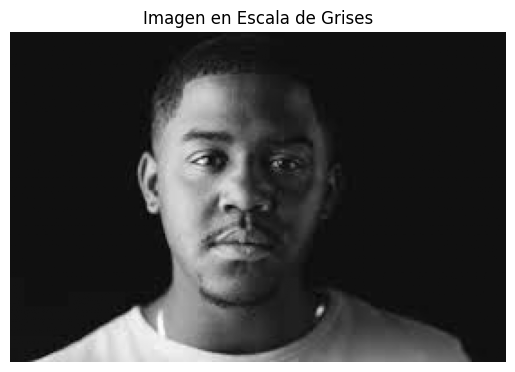

In [40]:
# Convertimos la imagen a escala de grises
# Esto reduce la imagen de 3 canales (color) a 1 canal (intensidad)
imagen_gris = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2GRAY)

# Mostramos la imagen en escala de grises
plt.imshow(imagen_gris, cmap="gray")
plt.title("Imagen en Escala de Grises")
plt.axis("off")
plt.show()

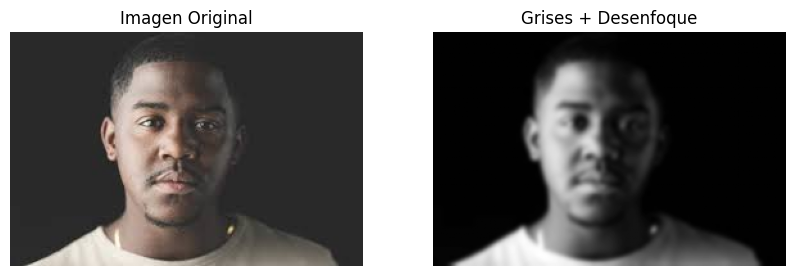

In [41]:
# Aplicamos un filtro de desenfoque Gaussiano
# El kernel (9x9) suaviza la imagen reduciendo ruido y detalles finos
imagen_blur = cv2.GaussianBlur(imagen_gris, (9, 9), 0)

# Creamos una figura para comparar imágenes
plt.figure(figsize=(10, 5))

# Subplot 1: Imagen original
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

# Subplot 2: Imagen procesada (grises + desenfoque)
plt.subplot(1, 2, 2)
plt.imshow(imagen_blur, cmap="gray")
plt.title("Grises + Desenfoque")
plt.axis("off")

# Mostramos ambas imágenes
plt.show()

### AUDIO:

Archivo de audio estéreo generado con éxito.


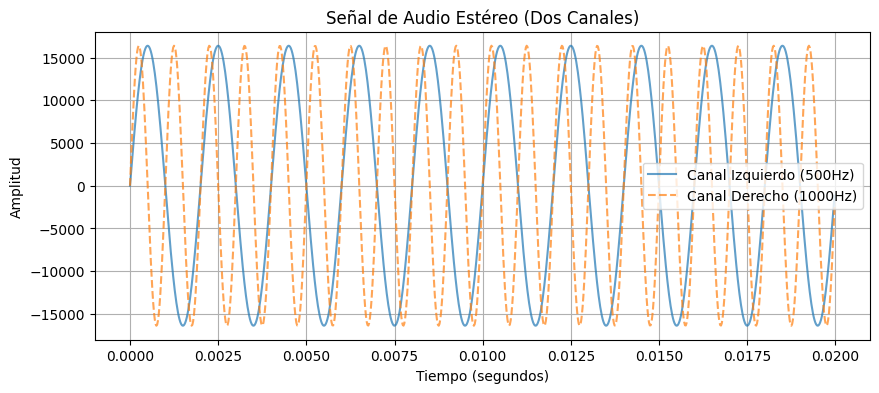

In [42]:
# Importamos las librerías necesarias
import numpy as np              # Permite trabajar con arreglos y generar señales (ondas)
import matplotlib.pyplot as plt # Se utiliza para graficar las señales de audio
import wave                     # Permite crear, leer y escribir archivos de audio WAV

# Ejemplo: Generar, guardar y cargar un archivo de audio estéreo
ruta_audio_estereo = "audio_estereo_generado.wav"

# 1. Generamos dos tonos puros (ondas senoidales) para cada canal
frecuencia_muestreo = 44100   # Frecuencia de muestreo estándar en audio (44.1 kHz)
duracion = 2.0                # Duración del audio en segundos
frec_izq = 500.0              # Frecuencia del canal izquierdo (Hz)
frec_der = 1000.0             # Frecuencia del canal derecho (Hz)

# Generamos el eje de tiempo
tiempo_gen = np.linspace(0, duracion, int(frecuencia_muestreo * duracion), endpoint=False)

# Creamos las ondas senoidales para cada canal
onda_izq = 0.5 * np.sin(2 * np.pi * frec_izq * tiempo_gen)
onda_der = 0.5 * np.sin(2 * np.pi * frec_der * tiempo_gen)

# Convertimos las ondas a enteros de 16 bits (formato estándar de audio)
onda_izq_int16 = np.int16(onda_izq * 32767)
onda_der_int16 = np.int16(onda_der * 32767)

# Intercalamos los datos para formar un audio estéreo [L, R, L, R...]
onda_estereo = np.empty((onda_izq_int16.size + onda_der_int16.size,), dtype=np.int16)
onda_estereo[0::2] = onda_izq_int16
onda_estereo[1::2] = onda_der_int16

# Guardamos el archivo de audio estéreo
with wave.open(ruta_audio_estereo, 'w') as wav_file:
    wav_file.setnchannels(2)          # 2 canales = estéreo
    wav_file.setsampwidth(2)          # 2 bytes = 16 bits
    wav_file.setframerate(frecuencia_muestreo)
    wav_file.writeframes(onda_estereo.tobytes())
    print("Archivo de audio estéreo generado con éxito.")

# 2. Cargamos el archivo de audio estéreo generado
try:
    with wave.open(ruta_audio_estereo, 'rb') as wav_file:
        frec_muestreo = wav_file.getframerate()
        n_frames = wav_file.getnframes()
        n_channels = wav_file.getnchannels()
        
        audio_data = wav_file.readframes(n_frames)
        audio_estereo = np.frombuffer(audio_data, dtype=np.int16)
        
        tiempo = np.arange(n_frames) / frec_muestreo
        
        plt.figure(figsize=(10, 4))
        
        if n_channels == 2:
            # Reorganizamos los datos en dos columnas (izquierdo y derecho)
            audio_estereo = audio_estereo.reshape(-1, 2)
            
            # Graficamos un segmento de los primeros 0.02 segundos
            segmento = int(frec_muestreo * 0.02)
            
            plt.plot(tiempo[:segmento], audio_estereo[:segmento, 0], label="Canal Izquierdo (500Hz)", alpha=0.7)
            plt.plot(tiempo[:segmento], audio_estereo[:segmento, 1], label="Canal Derecho (1000Hz)", alpha=0.7, linestyle='--')
        
        plt.title("Señal de Audio Estéreo (Dos Canales)")
        plt.xlabel("Tiempo (segundos)")
        plt.ylabel("Amplitud")
        plt.legend()
        plt.grid(True)
        plt.show()

except Exception as e:
    print(f"Error al procesar el audio estéreo: {e}")

### IoT:

Simulando datos de un sensor de luminosidad...
Muestra 1 - Luminosidad: 684.54 lux
Muestra 2 - Luminosidad: 858.73 lux
Muestra 3 - Luminosidad: 467.09 lux
Muestra 4 - Luminosidad: 622.29 lux
Muestra 5 - Luminosidad: 723.53 lux
Muestra 6 - Luminosidad: 397.90 lux
Muestra 7 - Luminosidad: 70.97 lux
Muestra 8 - Luminosidad: 977.60 lux
Muestra 9 - Luminosidad: 259.16 lux
Muestra 10 - Luminosidad: 375.86 lux
Muestra 11 - Luminosidad: 58.61 lux
Muestra 12 - Luminosidad: 131.31 lux
Muestra 13 - Luminosidad: 924.85 lux
Muestra 14 - Luminosidad: 883.15 lux
Muestra 15 - Luminosidad: 871.17 lux


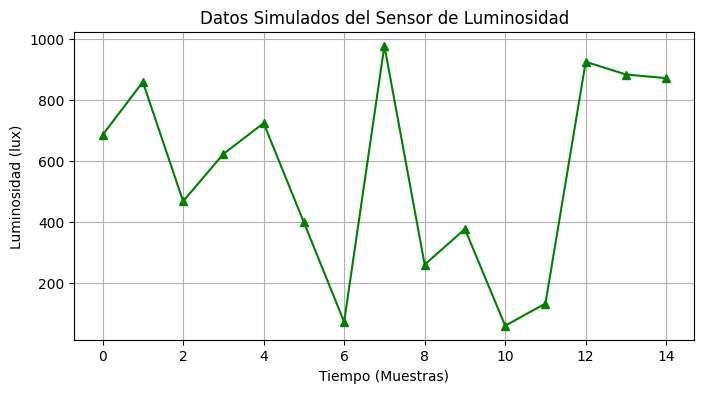

In [43]:
# Importamos las librerías necesarias
import random          # Permite generar valores aleatorios (simulación del sensor)
import time            # Permite simular pausas entre lecturas del sensor
import matplotlib.pyplot as plt  # Se utiliza para graficar los datos recolectados

# Ejemplo: Simulación de un sensor de luminosidad
def simular_luminosidad():
    # Simulamos una lectura de luminosidad devolviendo un valor aleatorio entre 0 y 1000 lux
    return random.uniform(0.0, 1000.0)

print("Simulando datos de un sensor de luminosidad...")
datos_luminosidad = []

# Recolectaremos 15 muestras
for i in range(15):
    luminosidad = simular_luminosidad()
    datos_luminosidad.append(luminosidad)
    print(f"Muestra {i+1} - Luminosidad: {luminosidad:.2f} lux")
    # time.sleep(0.2)  # Pausa breve simulando el tiempo de espera del sensor (comentado para no demorar)

# Graficamos la serie temporal de luminosidad
plt.figure(figsize=(8, 4))
plt.plot(datos_luminosidad, marker="^", color="green", linestyle='-')
plt.title("Datos Simulados del Sensor de Luminosidad")
plt.xlabel("Tiempo (Muestras)")
plt.ylabel("Luminosidad (lux)")
plt.grid(True)
plt.show()